In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)
pd.set_option("display.max_columns", None)

df = pd.read_csv("merged_df_with_tokens.csv")
df.head()

,id,review_title,review_rating,review_text,clean_review,sentiment_score,sentiment_label,bert_label,bert_confidence,title,year,genre,rating,tokens_processed,tokens
0,tt0369610,"Spielberg Magic, This Is Not. Still, a Visit t...",7.0,You may have heard some critics champion Juras...,you may have heard some critics champion juras...,0.9988,positive,negative,0.991350,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['may', 'heard', 'critic', 'champion', 'jurass...","['you', 'may', 'have', 'heard', 'some', 'criti..."
1,tt0369610,"Not a patch on the original Jurassic Park, and...",7.0,The original Jurassic Park still is a personal...,the original jurassic park still is a personal...,0.9986,positive,positive,0.943678,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['original', 'jurassic', 'park', 'still', 'per...","['the', 'original', 'jurassic', 'park', 'still..."
2,tt0369610,Its a Jurassic World after all.,7.0,The 4th film in the Jurassic Park series and t...,the th film in the jurassic park series and th...,-0.6089,negative,negative,0.999510,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['th', 'film', 'jurassic', 'park', 'series', '...","['the', 'th', 'film', 'in', 'the', 'jurassic',..."
3,tt0369610,Worthy Sequel To One Of The Greatest Films Eve...,0.0,Let's start this by stating how much of a die ...,lets start this by stating how much of a die h...,0.9947,positive,negative,0.991898,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['let', 'start', 'stating', 'much', 'die', 'ha...","['lets', 'start', 'this', 'by', 'stating', 'ho..."
4,tt0369610,Manages to somewhat return the Jurassic Park s...,6.0,Modernized and polished entry to the Jurassic ...,modernized and polished entry to the jurassic ...,0.8078,positive,positive,0.967235,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['modernized', 'polished', 'entry', 'jurassic'...","['modernized', 'and', 'polished', 'entry', 'to..."


In [15]:
df = df[df["bert_label"].isin(["positive", "negative"])].copy()

df["ml_label"] = df["bert_label"].map({"positive": 1, "negative": 0})
df = df.dropna(subset=["clean_review", "ml_label"])

df[["clean_review", "bert_label", "ml_label"]].head()

,clean_review,bert_label,ml_label
0,you may have heard some critics champion juras...,negative,0
1,the original jurassic park still is a personal...,positive,1
2,the th film in the jurassic park series and th...,negative,0
3,lets start this by stating how much of a die h...,negative,0
4,modernized and polished entry to the jurassic ...,positive,1


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df["clean_review"])
y = df["ml_label"]
X.shape, y.shape

((6241, 5000), (6241,))

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_clf = LogisticRegression(max_iter=300)
log_clf.fit(X_train, y_train)

y_pred_log = log_clf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7381905524419535
              precision    recall  f1-score   support

           0       0.73      0.57      0.64       514
           1       0.74      0.85      0.79       735

    accuracy                           0.74      1249
   macro avg       0.74      0.71      0.72      1249
weighted avg       0.74      0.74      0.73      1249



In [20]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC()
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.7053642914331465
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       514
           1       0.74      0.77      0.76       735

    accuracy                           0.71      1249
   macro avg       0.70      0.69      0.69      1249
weighted avg       0.70      0.71      0.70      1249



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7309847878302642
              precision    recall  f1-score   support

           0       0.75      0.53      0.62       514
           1       0.72      0.87      0.79       735

    accuracy                           0.73      1249
   macro avg       0.74      0.70      0.70      1249
weighted avg       0.73      0.73      0.72      1249



In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.738191
1,Linear SVM,0.705364
2,Random Forest,0.730985


In [23]:
df["ml_pred"] = svm_clf.predict(X)
df[["clean_review", "bert_label", "ml_pred"]].head()

,clean_review,bert_label,ml_pred
0,you may have heard some critics champion juras...,negative,1
1,the original jurassic park still is a personal...,positive,1
2,the th film in the jurassic park series and th...,negative,1
3,lets start this by stating how much of a die h...,negative,0
4,modernized and polished entry to the jurassic ...,positive,1


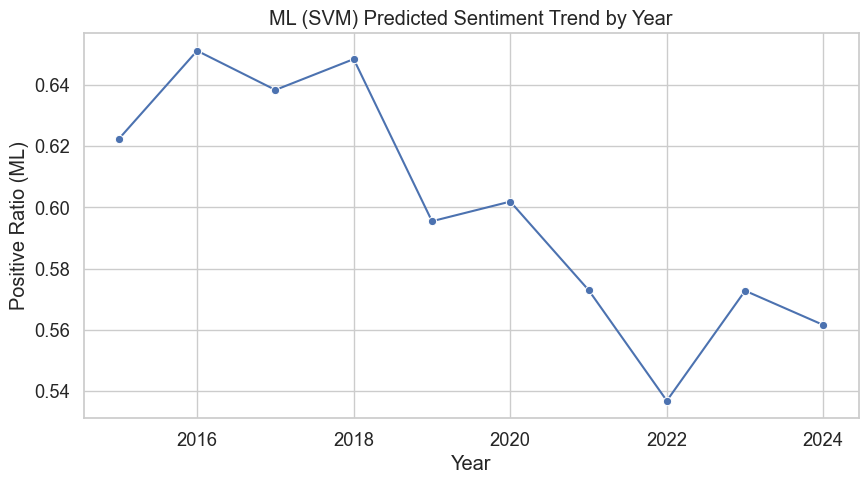

In [24]:
yearly_ml = df.groupby("year")["ml_pred"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_ml, x="year", y="ml_pred", marker="o")
plt.title("ML (SVM) Predicted Sentiment Trend by Year")
plt.xlabel("Year")
plt.ylabel("Positive Ratio (ML)")
plt.show()

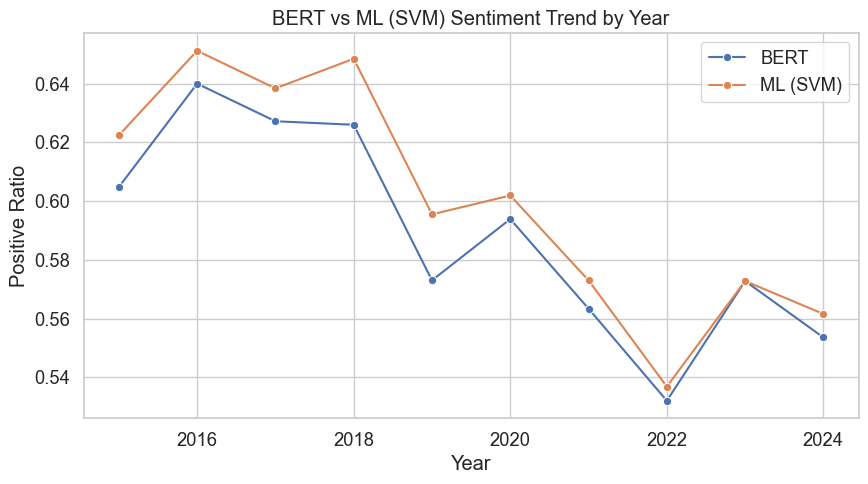

In [25]:
df["bert_binary"] = df["bert_label"].map({"positive": 1, "negative": 0})

yearly_compare = (
    df.groupby("year")[["bert_binary", "ml_pred"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_compare, x="year", y="bert_binary", marker="o", label="BERT")
sns.lineplot(data=yearly_compare, x="year", y="ml_pred", marker="o", label="ML (SVM)")
plt.title("BERT vs ML (SVM) Sentiment Trend by Year")
plt.xlabel("Year")
plt.ylabel("Positive Ratio")
plt.legend()
plt.show()

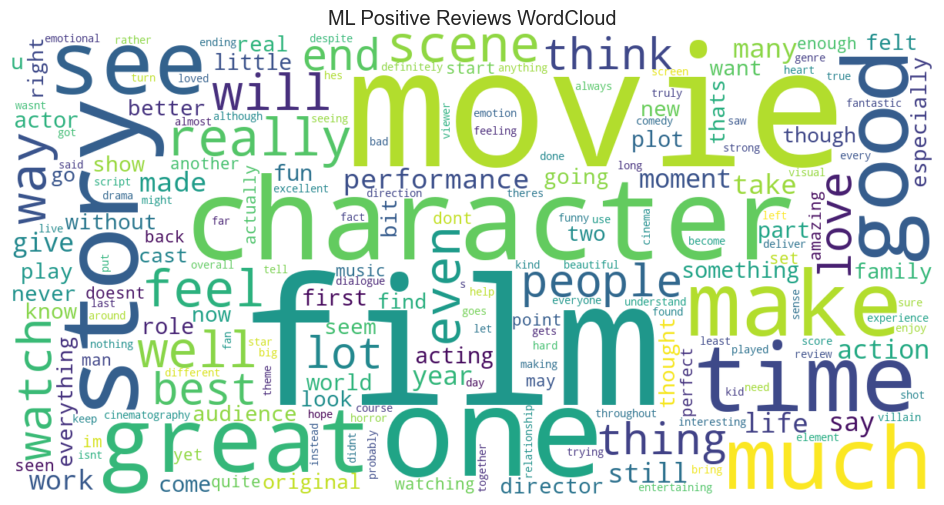

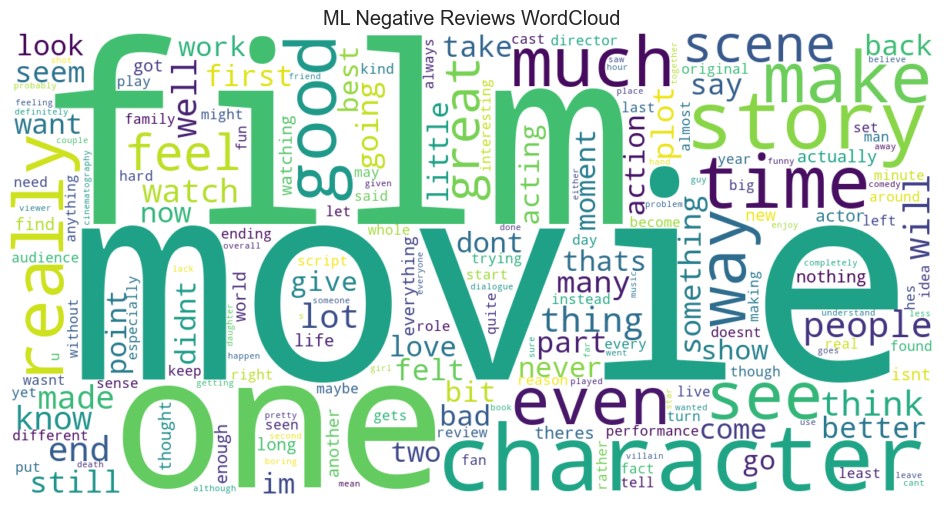

In [27]:
from wordcloud import WordCloud

pos_text = " ".join(df[df["ml_pred"] == 1]["clean_review"].astype(str))
neg_text = " ".join(df[df["ml_pred"] == 0]["clean_review"].astype(str))

wc_pos = WordCloud(width=1200, height=600, background_color="white").generate(pos_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("ML Positive Reviews WordCloud")
plt.show()

wc_neg = WordCloud(width=1200, height=600, background_color="white").generate(neg_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("ML Negative Reviews WordCloud")
plt.show()

In [35]:
df.to_csv("merged_df_with_ml.csv", index=False)

## VADER VS BERT VS ML

In [36]:
merged_df = pd.read_csv("merged_df_with_ml.csv")
df.head()

,id,review_title,review_rating,review_text,clean_review,sentiment_score,sentiment_label,bert_label,bert_confidence,title,year,genre,rating,tokens_processed,tokens,ml_label,ml_pred,bert_binary
0,tt0369610,"Spielberg Magic, This Is Not. Still, a Visit t...",7.0,You may have heard some critics champion Juras...,you may have heard some critics champion juras...,0.9988,positive,negative,0.991350,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['may', 'heard', 'critic', 'champion', 'jurass...","['you', 'may', 'have', 'heard', 'some', 'criti...",0,1,0
1,tt0369610,"Not a patch on the original Jurassic Park, and...",7.0,The original Jurassic Park still is a personal...,the original jurassic park still is a personal...,0.9986,positive,positive,0.943678,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['original', 'jurassic', 'park', 'still', 'per...","['the', 'original', 'jurassic', 'park', 'still...",1,1,1
2,tt0369610,Its a Jurassic World after all.,7.0,The 4th film in the Jurassic Park series and t...,the th film in the jurassic park series and th...,-0.6089,negative,negative,0.999510,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['th', 'film', 'jurassic', 'park', 'series', '...","['the', 'th', 'film', 'in', 'the', 'jurassic',...",0,1,0
3,tt0369610,Worthy Sequel To One Of The Greatest Films Eve...,0.0,Let's start this by stating how much of a die ...,lets start this by stating how much of a die h...,0.9947,positive,negative,0.991898,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['let', 'start', 'stating', 'much', 'die', 'ha...","['lets', 'start', 'this', 'by', 'stating', 'ho...",0,0,0
4,tt0369610,Manages to somewhat return the Jurassic Park s...,6.0,Modernized and polished entry to the Jurassic ...,modernized and polished entry to the jurassic ...,0.8078,positive,positive,0.967235,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9,"['modernized', 'polished', 'entry', 'jurassic'...","['modernized', 'and', 'polished', 'entry', 'to...",1,1,1


In [37]:
merged_df.columns.tolist()

['id',
 'review_title',
 'review_rating',
 'review_text',
 'clean_review',
 'sentiment_score',
 'sentiment_label',
 'bert_label',
 'bert_confidence',
 'title',
 'year',
 'genre',
 'rating',
 'tokens_processed',
 'tokens',
 'ml_label',
 'ml_pred',
 'bert_binary']

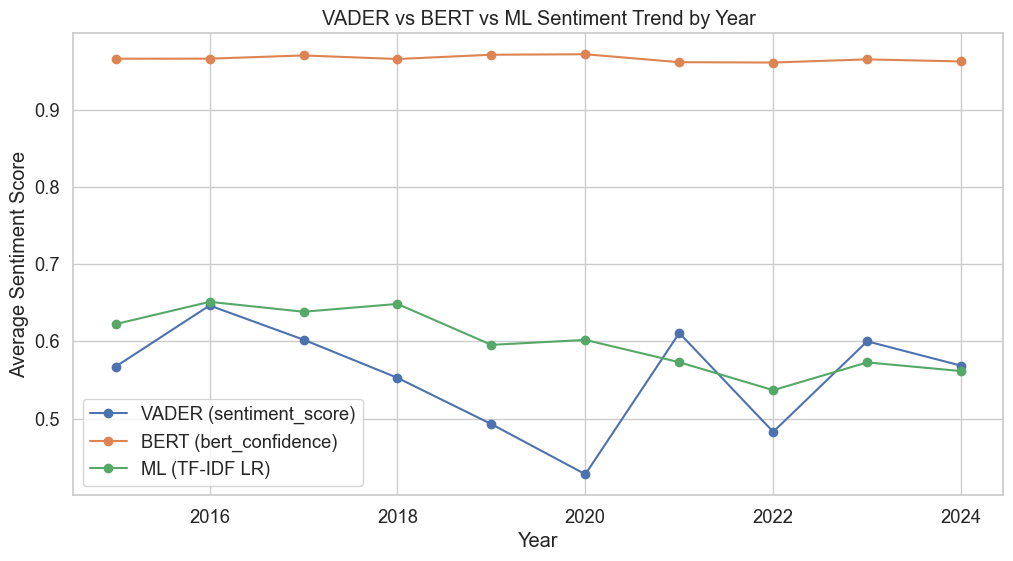

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

merged_df = pd.read_csv("merged_df_with_ml.csv")

yearly = (
    merged_df.groupby("year")[["sentiment_score", "bert_confidence", "ml_pred"]]
             .mean()
             .reset_index()
             .rename(columns={
                 "sentiment_score": "vader_avg",
                 "bert_confidence": "bert_avg",
                 "ml_pred": "ml_avg"
             })
)

plt.figure(figsize=(12,6))

plt.plot(yearly["year"], yearly["vader_avg"], marker="o", label="VADER (sentiment_score)")
plt.plot(yearly["year"], yearly["bert_avg"], marker="o", label="BERT (bert_confidence)")
plt.plot(yearly["year"], yearly["ml_avg"], marker="o", label="ML (TF-IDF LR)")

plt.title("VADER vs BERT vs ML Sentiment Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.grid(True)
plt.legend()
plt.show()